# 1 - Carregando Bibliotecas e Dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sys

try:
    from utils import iv_woe, print_correlacao, analise_quantil
except ImportError:
    sys.path.append('../utils')
    from utils import iv_woe, print_correlacao, analise_quantil

In [2]:
# Lendo o dataset diretamente do repositório do GitHub e salvando localmente
df = pd.read_csv("https://raw.githubusercontent.com/AnaRaquelCafe/POSTECH_AI_SCIENTIST/refs/heads/main/Base%20de%20dados%20Tech%20Challenge/desafio_nps_fase_1.csv")
df.to_csv("../data/external/desafio_nps_fase_1.csv", index=False)

## 1.1 - Visão geral do DataFrame

In [3]:
df.shape

(2500, 19)

In [4]:
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


# 2 - Analisando as métricas do dataframe

## 2.1 - Tipos de Colunas e dados vazios

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

Possuímos 3 diferentes tipos de colunas:
- int64: 13 colunas
- float64: 5 colunas
- str: 1 coluna

Total: 18 colunas numéricas e 1 não numérica.

Além disso, **não existem** dados nulos no dataset.

## 2.2 - Visualizando as métricas de estatística descritiva

In [6]:
df.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


# 3 - Analisando os dados em busca de insights

## 3.1 - Analisando a variável `nps_score`

Antes de analisar o NPS, é importante entender o conceito da métrica. <br>
O NPS (Net Promoter Score) é uma métrica usada para medir o nível de satisfação e lealdade dos clientes em relação a uma empresa, produto ou serviço.

Ele se baseia em uma única pergunta:
> “Em uma escala de 0 a 10, o quanto você recomendaria nossa empresa/produto/serviço a um amigo ou colega?”

**Classificação dos Clientes**:
- Promotores (9-10): Clientes fiéis e entusiastas que promovem a marca.
- Passivos/Neutros (7-8): Satisfeitos, mas não leais, vulneráveis à concorrência.
- Detratores (0-6): Clientes insatisfeitos que podem prejudicar a reputação.

In [7]:
# Métricas de estatística descritiva do NPS
df[['nps_score']].describe()

,nps_score
count,2500.000000
mean,4.378600
std,2.510229
min,0.000000
25%,2.600000
50%,4.400000
75%,6.100000
max,10.000000


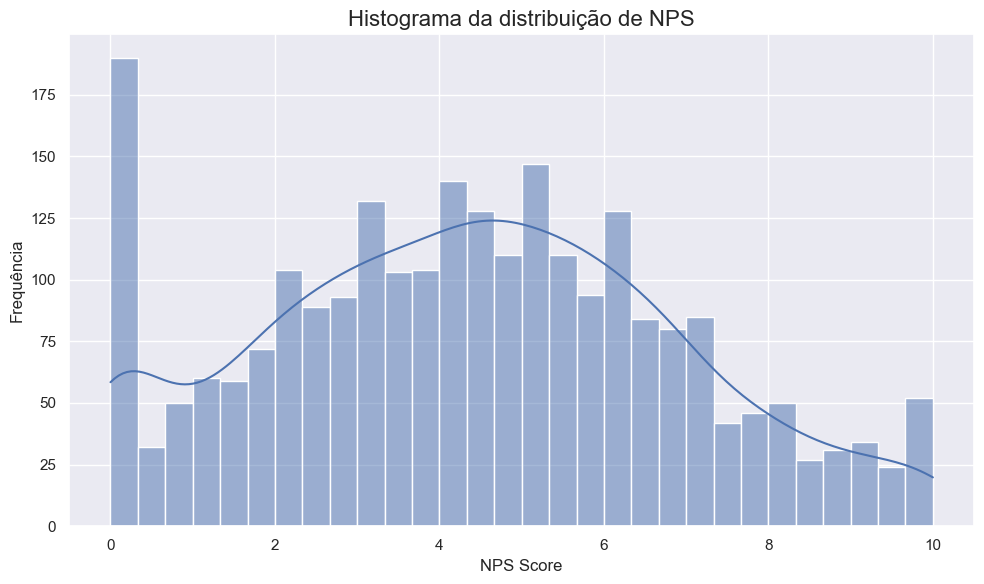

In [8]:
# Visualizando a distribuição do NPS de forma gráfica

# Estilo visual
sns.set_theme(style="darkgrid")

# Criar o histograma
plt.figure(figsize=(10, 6))
sns.histplot(
    df.nps_score,
    bins=30,
    kde=True,
    color="#4C72B0"
)

# Títulos e rótulos
plt.title("Histograma da distribuição de NPS", fontsize=16)
plt.xlabel("NPS Score", fontsize=12)
plt.ylabel("Frequência", fontsize=12)

plt.tight_layout()
plt.show()

A partir dessa visualização, é possível notar que existem concentrações em notas muito baixas - próximas ou iguais a zero - e muito altas - próximas ou iguais a 10. <br>
Fora destas concentrações, a distribuição apresenta formato aproximadamente normal, com leve assimetria e limites superiores e inferiores impostos pela escala.

Para as seguintes análises, iremos analisar:
1. A base completa
2. A base de clientes apenas com NPS 0 -> causas da nota 0 <br>
3. A base de clientes apenas com NPS 10 -> causas da nota 10 <br>
4. A base de clientes com NPS aproximadamente normal (apenas notas diferentes de 0 e 10)

## 3.2 - Analisando o Dataset completo

In [9]:
df.shape

(2500, 19)

### 3.2.1 - Verificando a correlação entre as variáveis numéricas do dataset

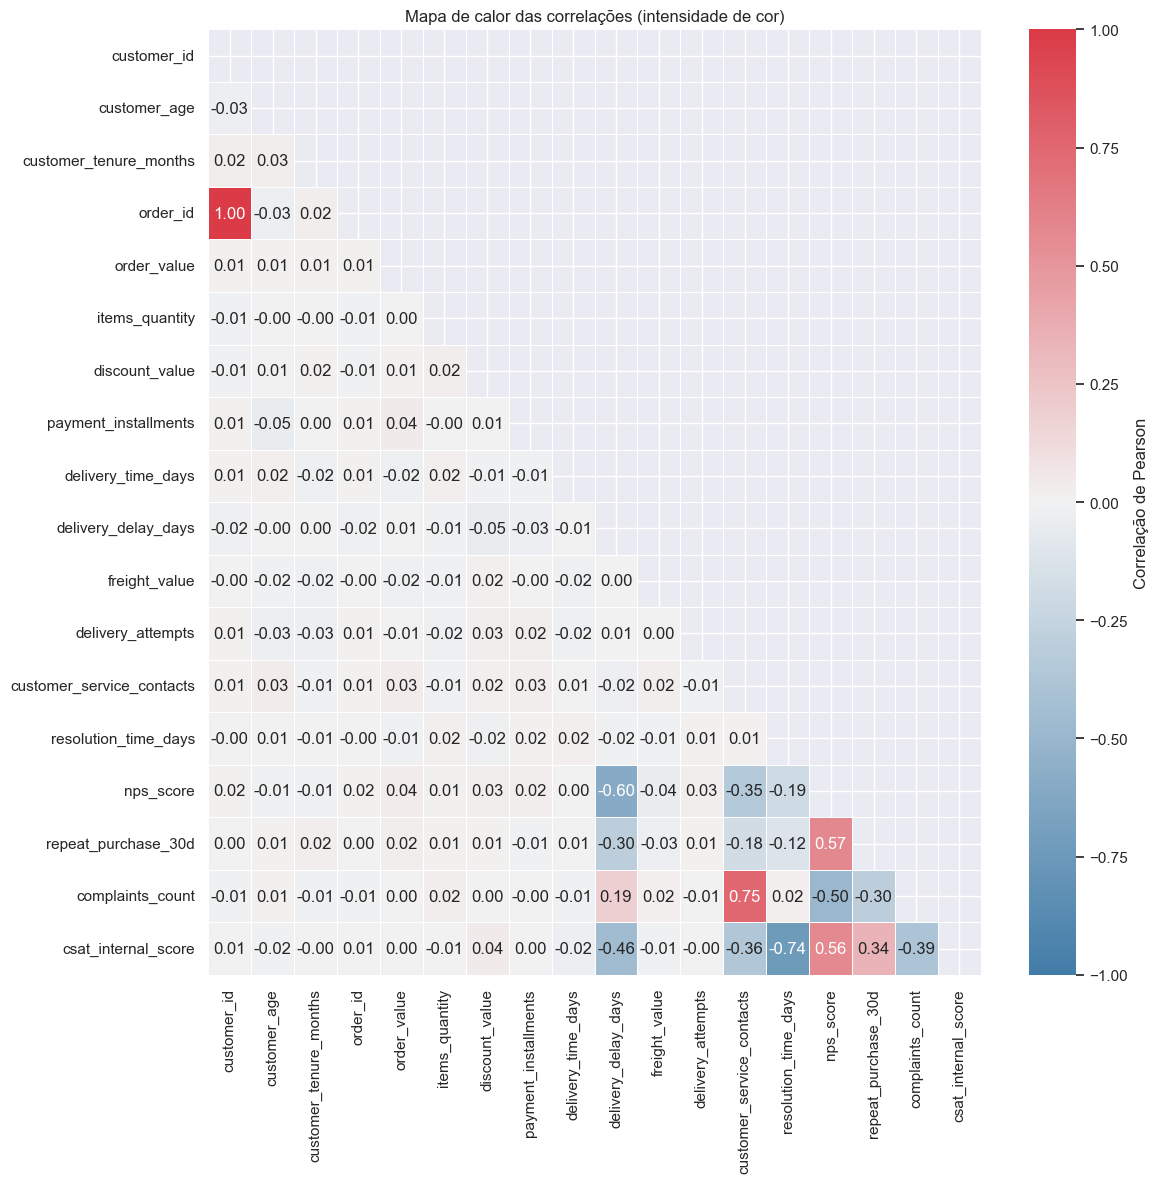

In [10]:
resultado = print_correlacao(df)

Observando a correlação entre NPS e as outras variáveis, é possível notar a relação com 6 features que se destacam. <br> <br>
**4 correlações negativas**:
- delivery_delay_days (-0.60)
- complaints_count (-0.50)
- customer_service_contacts (-0.35)
- resolution_time_days (-0.19)

**2 correlações positivas**:
- repeat_purchase_30d (0.57)
- csat_internal_score (0.56)

Visto que a única variável categórica `customer_region` não foi contemplada nesta análise, será feito uma analise apartada. <br>

À princípio, supos-se que a região do cliente pode ter influência no atraso da entrega, visto que a malha logística pode variar de acordo com a região. <br>
Dessa forma, faremos uma análise tanto do NPS quanto do atraso de entrega por região.

In [11]:
df.groupby('customer_region').agg({'nps_score': 'mean', 'delivery_delay_days': 'mean', 'delivery_time_days':'mean'})

,nps_score,delivery_delay_days,delivery_time_days
customer_region,,,
Centro-Oeste,4.209829,2.222222,7.912393
Nordeste,4.421649,2.185567,8.160825
Norte,4.382609,2.144269,7.758893
Sudeste,4.373846,2.217308,8.201923
Sul,4.490979,2.168906,8.067179


A partir desta análise, é possível notar que essa variável não exerce grande influência tanto no `nps_score`, quanto em `delivery_delay_days`.

### 3.2.2 - Analisando a tendência de cada feature em relação ao NPS
O que os dados nos dizem sobre a relação entre as variáveis e o NPS? Será plotado a divisão das features em decis e suas médias para diminuir a variação dos dados e observar apenas a tendência.

In [12]:
df.columns

Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score'],
      dtype='str')

#### Variável `customer_age`

         min_val  max_val
quantil                  
1             18       23
2             24       28
3             29       34
4             35       38
5             39       43
6             44       48
7             49       54
8             55       59
9             60       64
10            65       69


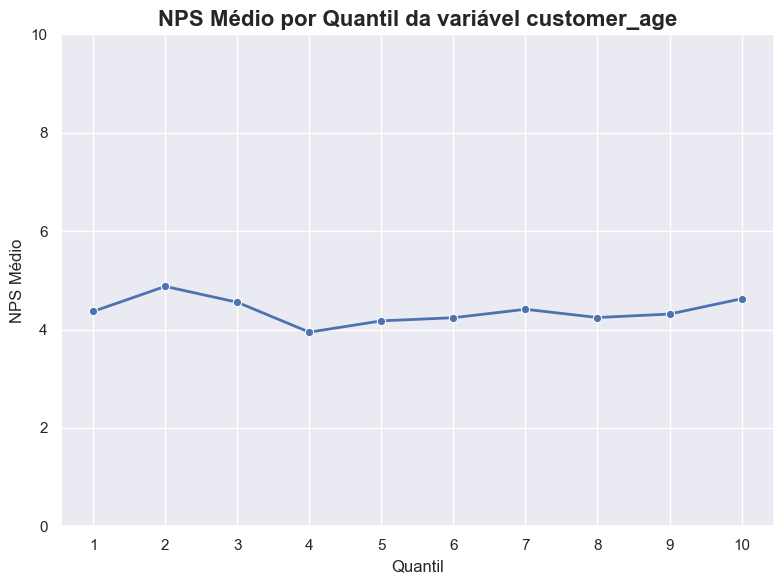

In [13]:
analise_quantil(df, 'customer_age')

Não é possível detectar grandes mudanças no NPS de acordo com a variação da variável

#### Variável `customer_tenure_months`

         min_val  max_val
quantil                  
1              1       13
2             14       25
3             26       37
4             38       50
5             51       62
6             63       74
7             75       84
8             85       96
9             97      109
10           110      119


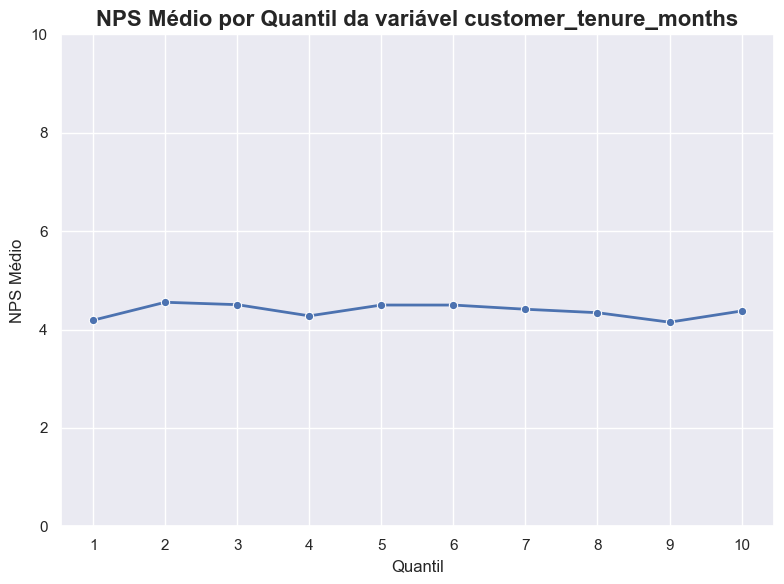

In [14]:
analise_quantil(df, 'customer_tenure_months')

Não é possível detectar grandes mudanças no NPS de acordo com a variação da variável

#### Variável `order_value`

         min_val  max_val
quantil                  
1           7.76   126.52
2         126.73   191.56
3         191.86   249.43
4         250.52   312.04
5         312.27   375.46
6         375.57   446.05
7         446.12   525.26
8         525.67   639.58
9         639.78   825.63
10        825.72  1983.81


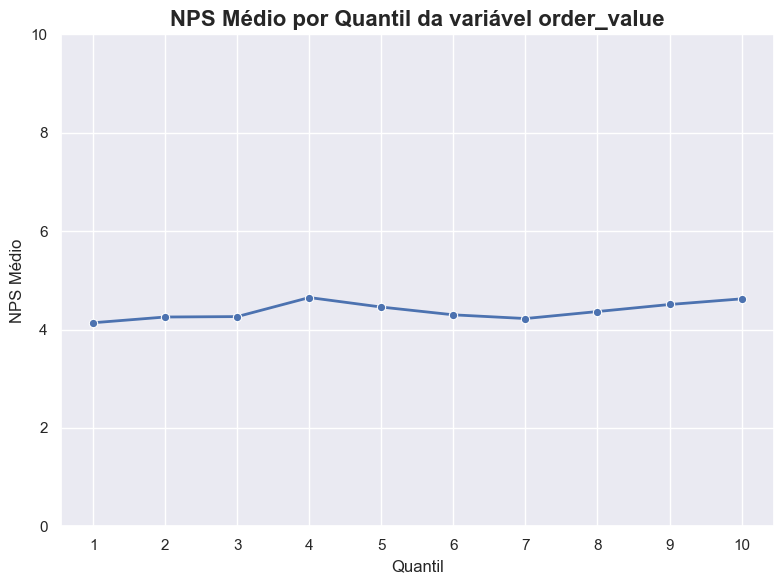

In [15]:
analise_quantil(df, 'order_value')

Não é possível detectar grandes mudanças no NPS de acordo com a variação da variável

#### Variável `items_quantity`

         min_val  max_val
quantil                  
1              1        2
2              3        3
3              4        4
4              5        5
5              6        6


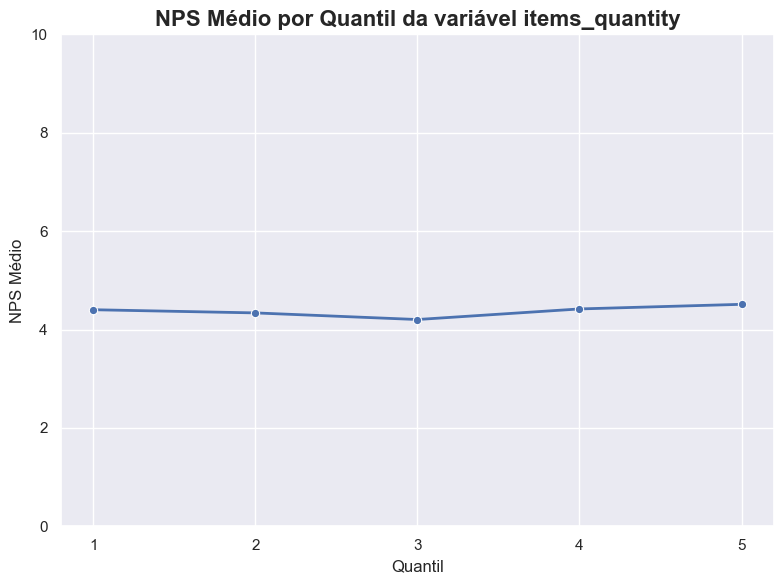

In [16]:
analise_quantil(df, 'items_quantity')

Não é possível detectar grandes mudanças no NPS de acordo com a variação da variável

#### Variável `discount_value`

         min_val  max_val
quantil                  
1           0.02     3.05
2           3.06     6.81
3           6.83    11.18
4          11.19    15.61
5          15.62    20.89
6          20.98    27.55
7          27.57    36.04
8          36.10    47.45
9          47.48    68.44
10         68.52   230.33


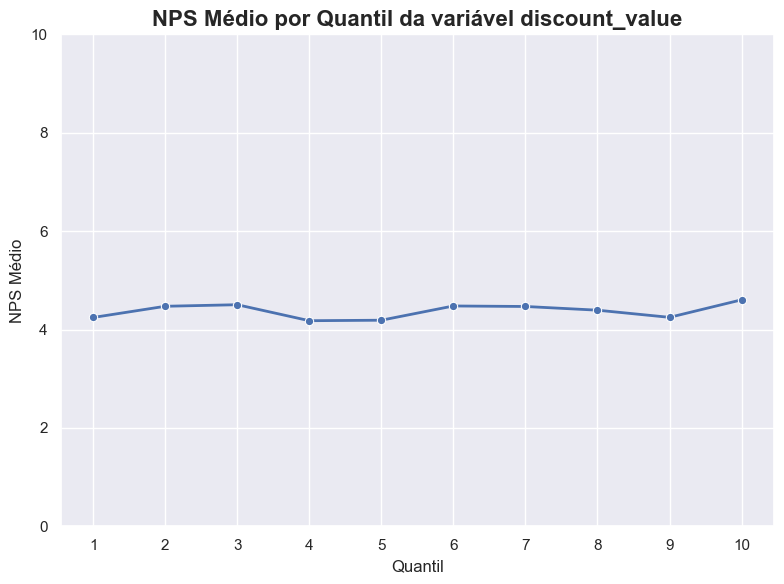

In [17]:
analise_quantil(df, 'discount_value')

Não é possível detectar grandes mudanças no NPS de acordo com a variação da variável

#### Variável `payment_installments`

         min_val  max_val
quantil                  
1              1        2
2              3        3
3              4        4
4              5        5
5              6        6
6              7        7
7              8        8
8              9        9
9             10       10
10            11       11


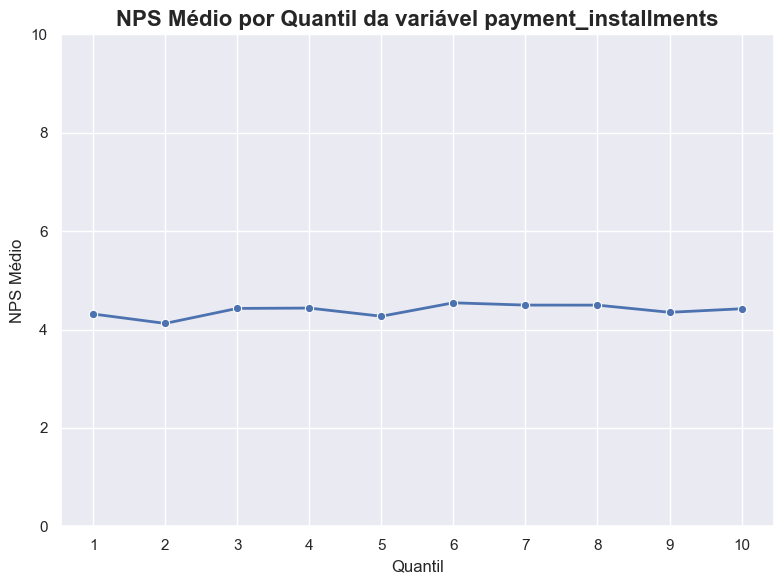

In [18]:
analise_quantil(df, 'payment_installments')

Não é possível detectar grandes mudanças no NPS de acordo com a variação da variável

#### Variável `delivery_time_days`

         min_val  max_val
quantil                  
1              2        3
2              4        4
3              5        5
4              6        7
5              8        8
6              9        9
7             10       11
8             12       12
9             13       13
10            14       14


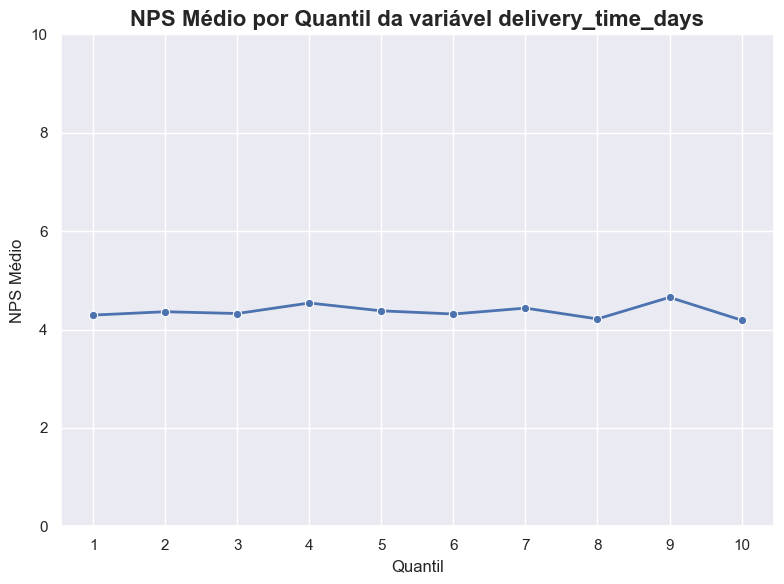

In [19]:
analise_quantil(df, 'delivery_time_days')

Não é possível detectar grandes mudanças no NPS de acordo com a variação da variável

#### Variável `delivery_delay_days`

         min_val  max_val
quantil                  
1              0        1
2              2        2
3              3        3
4              4        4
5              5        8


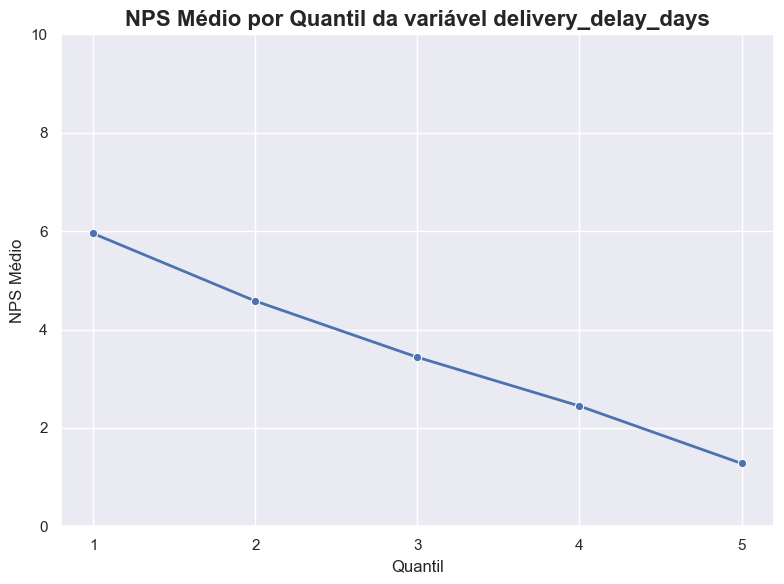

In [20]:
analise_quantil(df, 'delivery_delay_days')

É possível observar mudança significativa no NPS e uma relação inversamente proporcional entre o atraso na entrega e o NPS.

#### Variável `freight_value`

         min_val  max_val
quantil                  
1           2.62    22.33
2          22.38    27.94
3          27.96    31.93
4          31.94    35.22
5          35.24    38.50
6          38.52    41.54
7          41.56    44.64
8          44.65    48.09
9          48.10    53.94
10         53.95    76.13


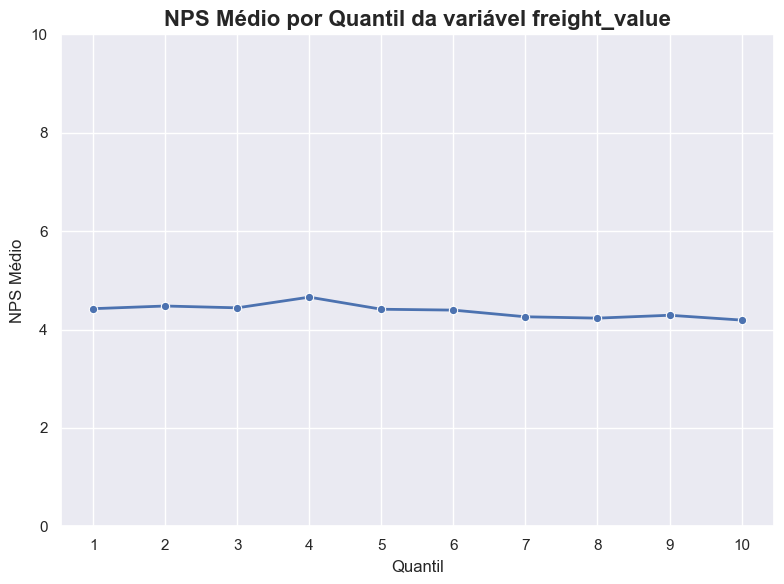

In [21]:
analise_quantil(df, 'freight_value')

Não é possível detectar grandes mudanças no NPS de acordo com a variação da variável

#### Variável `delivery_attempts`

         min_val  max_val
quantil                  
1              1        2
2              3        3


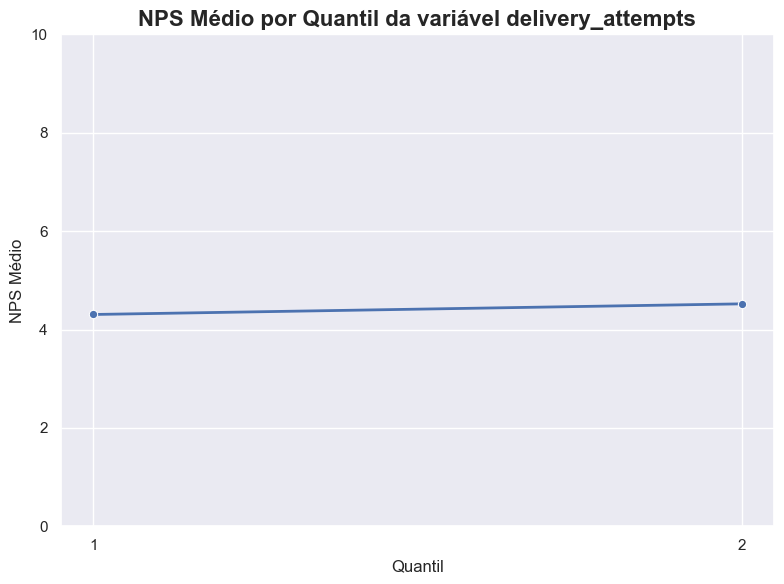

In [22]:
analise_quantil(df, 'delivery_attempts')

Não é possível detectar grandes mudanças no NPS de acordo com a variação da variável

#### Variável `customer_service_contacts`

         min_val  max_val
quantil                  
1              0        1
2              2        2
3              3        3
4              4        7


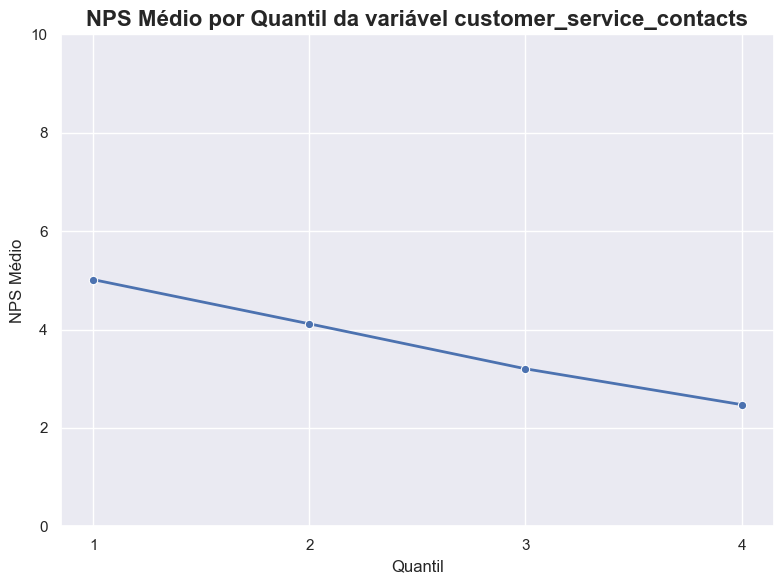

In [23]:
analise_quantil(df, 'customer_service_contacts')

É possível observar mudança significativa no NPS e uma relação inversamente proporcional entre a quantidade de contatos com o SAC e o NPS.

#### Variável `resolution_time_days`

         min_val  max_val
quantil                  
1              0        1
2              2        2
3              3        3
4              4        4
5              5        6
6              7        7
7              8        8
8              9        9
9             10       10
10            11       11


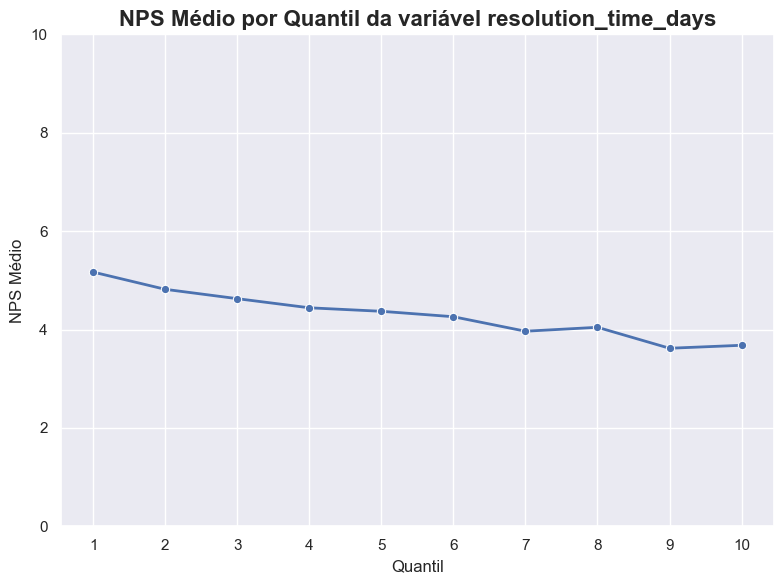

In [24]:
analise_quantil(df, 'resolution_time_days')

É possível observar mudança significativa no NPS e uma relação inversamente proporcional entre a quantidade de dias até a resolução e o NPS.

#### Variável `complaints_count`

         min_val  max_val
quantil                  
1              0        2
2              3        3
3              4        4
4              5        5
5              6        6
6              7        7
7              8       11


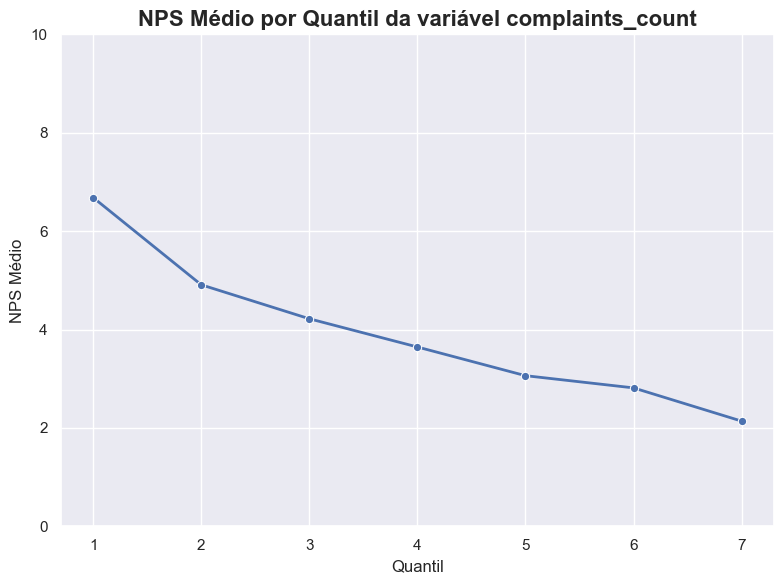

In [25]:
analise_quantil(df, 'complaints_count')

É possível observar mudança significativa no NPS e uma relação inversamente proporcional entre a quantidade de reclamações e o NPS.

#### Variável `csat_internal_score`

         min_val  max_val
quantil                  
1            0.0      0.2
2            0.3      1.2
3            1.3      2.0
4            2.1      2.8
5            2.9      3.5
6            3.6      4.3
7            4.4      5.2
8            5.3      6.3
9            6.4     10.0


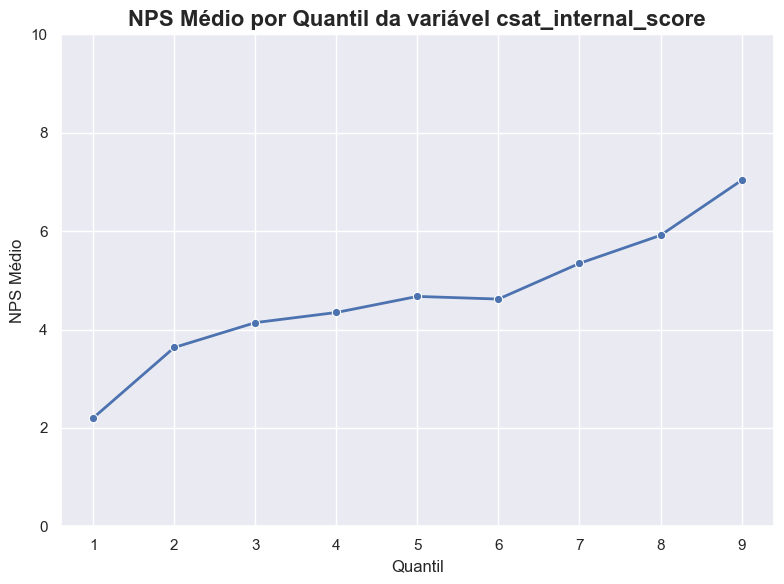

In [26]:
analise_quantil(df, 'csat_internal_score')

É possível observar mudança significativa no NPS e uma relação diretamente proporcional entre o atraso na entrega e o csat_internal_score.

**OBS**: <br>
As relações das colunas customer_id e order_id não foram estudadas porque são identificadores do cliente e não trazem informação relevante para o estudo. <br>
Além disso, não é possível realizar a mesma análise para as colunas customer_region (categórica) e repeat_purchase_30d (booleana)

## 3.3 - Analisando o Dataset com `nps_score` == 0

In [27]:
df_zero = df[df['nps_score'] == 0]

In [28]:
# Dimensão do dataset
df_zero.shape

(158, 19)

In [29]:
# Analisando as estatísticas descritivas do subset
df_zero.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.0,158.0,158.000000,158.000000
mean,1167.993671,44.645570,61.715190,51167.993671,417.211203,3.322785,28.307468,6.094937,8.164557,4.107595,39.106456,1.943038,2.651899,6.348101,0.0,0.0,5.759494,0.701899
std,645.949876,13.720632,33.793696,645.949876,281.148379,1.640526,25.820934,3.117217,3.855447,1.482748,12.022180,0.823567,1.427336,3.311680,0.0,0.0,1.835358,1.260951
min,8.000000,18.000000,1.000000,50008.000000,14.580000,1.000000,0.100000,1.000000,2.000000,1.000000,6.130000,1.000000,0.000000,0.000000,0.0,0.0,2.000000,0.000000
25%,611.750000,35.000000,34.250000,50611.750000,218.547500,2.000000,8.780000,3.000000,5.000000,3.000000,30.180000,1.000000,1.250000,4.000000,0.0,0.0,4.000000,0.000000
50%,1159.000000,45.500000,61.500000,51159.000000,368.575000,3.000000,20.920000,6.000000,8.000000,4.000000,40.285000,2.000000,3.000000,6.500000,0.0,0.0,6.000000,0.000000
75%,1737.000000,56.750000,89.750000,51737.000000,526.862500,5.000000,41.777500,9.000000,12.000000,5.000000,47.222500,3.000000,4.000000,9.000000,0.0,0.0,7.000000,0.900000
max,2454.000000,69.000000,118.000000,52454.000000,1842.300000,6.000000,129.590000,11.000000,14.000000,8.000000,66.870000,3.000000,7.000000,11.000000,0.0,0.0,10.000000,5.200000


É possível notar que, quando o NPS é zerado, não existe casos em que houve compra dentro de uma janela de 30 dias.

### 3.3.1 - Comparando a diferença entre as médias do dataset completo e do subset com NPS igual a zero

In [30]:
df_compare = pd.DataFrame()

df_compare['zero_mean'] = df_zero.describe().loc['mean']
df_compare['complete_mean'] = df.describe().loc['mean']
df_compare['perc_diff'] = 100*(df_compare['zero_mean'] - df_compare['complete_mean'])/df_compare['complete_mean']

df_compare['perc_diff']

customer_id                   -6.597867
customer_age                   2.879458
customer_tenure_months         0.640532
order_id                      -0.160986
order_value                   -3.925885
items_quantity                -4.264584
discount_value                -4.834835
payment_installments           1.514602
delivery_time_days             1.777075
delivery_delay_days           87.801524
freight_value                  2.327339
delivery_attempts             -3.119367
customer_service_contacts     74.512946
resolution_time_days          15.723007
nps_score                   -100.000000
repeat_purchase_30d         -100.000000
complaints_count              38.769605
csat_internal_score          -76.138879
Name: perc_diff, dtype: float64

É possível notar grandes alterações no comportamento de clientes com NPS igual a zero em relação à média da população geral, principalemente nos seguintes pontos:
- delivery_delay_days
- customer_service_contacts
- resolution_time_days
- nps_score (naturalmente, já que o nps da população estudada é 0)
- repeat_purchase_30d (não existem casos de recompra caso o nps seja igual a 0)
- complaints_count
- csat_internal_score

## 3.4 - Analisando o Dataset com `nps_score` == 10

In [31]:
df_dez = df[df['nps_score'] == 10]
# Dimensão do dataset
df_dez.shape

(42, 19)

In [32]:
# Analisando as estatísticas descritivas do subset
df_dez.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.0,42.0,42.000000,42.000000
mean,1198.071429,39.571429,63.785714,51198.071429,455.277857,3.380952,32.800476,5.500000,7.642857,0.571429,36.918810,2.023810,0.571429,3.761905,10.0,1.0,1.952381,6.369048
std,724.558483,14.687215,32.937143,724.558483,210.305520,1.560994,28.707291,3.094054,3.881296,0.630248,13.144464,0.869205,0.769633,3.573681,0.0,0.0,1.342593,2.346090
min,23.000000,18.000000,9.000000,50023.000000,94.640000,1.000000,0.350000,1.000000,2.000000,0.000000,12.040000,1.000000,0.000000,0.000000,10.0,1.0,0.000000,1.500000
25%,503.750000,26.250000,35.250000,50503.750000,299.395000,2.000000,7.852500,3.000000,5.000000,0.000000,26.795000,1.000000,0.000000,1.000000,10.0,1.0,1.000000,4.925000
50%,1237.000000,35.000000,66.000000,51237.000000,415.575000,3.500000,28.560000,5.000000,7.500000,0.500000,34.570000,2.000000,0.000000,3.000000,10.0,1.0,2.000000,6.850000
75%,1822.000000,50.750000,83.750000,51822.000000,560.875000,5.000000,44.087500,8.000000,11.000000,1.000000,44.740000,3.000000,1.000000,6.750000,10.0,1.0,3.000000,8.275000
max,2500.000000,67.000000,119.000000,52500.000000,1086.460000,6.000000,101.980000,11.000000,14.000000,2.000000,69.430000,3.000000,3.000000,11.000000,10.0,1.0,4.000000,9.900000


### 3.4.1 - Comparando a diferença entre as médias do dataset completo e do subset com NPS igual a dez

In [33]:
df_compare = pd.DataFrame()

df_compare['dez_mean'] = df_dez.describe().loc['mean']
df_compare['complete_mean'] = df.describe().loc['mean']
df_compare['perc_diff'] = 100*(df_compare['dez_mean'] - df_compare['complete_mean'])/df_compare['complete_mean']

df_compare['perc_diff']

customer_id                    -4.192609
customer_age                   -8.813189
customer_tenure_months          4.016989
order_id                       -0.102299
order_value                     4.839988
items_quantity                 -2.588672
discount_value                 10.269936
payment_installments           -8.394404
delivery_time_days             -4.726288
delivery_delay_days           -73.873968
freight_value                  -3.396933
delivery_attempts               0.907934
customer_service_contacts     -62.396119
resolution_time_days          -31.422182
nps_score                     128.383502
repeat_purchase_30d          1046.788991
complaints_count              -52.959210
csat_internal_score           116.516441
Name: perc_diff, dtype: float64

É possível notar grandes alterações no comportamento de clientes com NPS igual a dez em relação à média da população geral, principalemente nos seguintes pontos:
- delivery_delay_days
- customer_service_contacts
- resolution_time_days
- nps_score (naturalmente, já que a nota do subset é 10)
- repeat_purchase_30d (a diferença mais notável: quando o NPS é 10, o cliente possui uma chance 10x maior de comprar novamente dentro de 30 dias em relação ao público geral)
- complaints_count
- csat_internal_score

## 3.5 - Analisando o Dataset com `nps_score` diferente de 0 e 10

In [34]:
df_filt = df[(df['nps_score'] != 10) & (df['nps_score'] != 0)]
# Dimensão do dataset
df_filt.shape

(2300, 19)

In [35]:
# Analisando as estatísticas descritivas do subset
df_filt.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.00000
mean,1257.125217,43.380000,61.250435,51257.125217,435.047091,3.482609,29.788630,6.006957,8.019130,2.084783,38.179622,2.009565,1.459130,5.457826,4.576739,0.076522,4.080000,3.03287
std,726.602065,14.962384,34.564977,726.602065,291.646078,1.692846,29.460119,3.164333,3.763632,1.352983,12.061510,0.814129,1.179268,3.451832,2.217033,0.265889,1.710861,2.31891
min,1.000000,18.000000,1.000000,50001.000000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.00000
25%,628.750000,31.000000,31.000000,50628.750000,218.652500,2.000000,8.917500,3.000000,5.000000,1.000000,29.960000,1.000000,1.000000,2.000000,2.900000,0.000000,3.000000,1.00000
50%,1257.500000,43.000000,62.000000,51257.500000,375.515000,3.000000,20.845000,6.000000,8.000000,2.000000,38.435000,2.000000,1.000000,5.000000,4.500000,0.000000,4.000000,2.90000
75%,1895.250000,56.000000,91.000000,51895.250000,584.925000,5.000000,40.650000,9.000000,11.000000,3.000000,46.250000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.80000
max,2499.000000,69.000000,119.000000,52499.000000,1983.810000,6.000000,230.330000,11.000000,14.000000,7.000000,76.130000,3.000000,7.000000,11.000000,9.900000,1.000000,11.000000,10.00000


### 3.5.1 - Comparando a diferença entre as médias do dataset completo e do subset com NPS diferente de zero e dez

In [36]:
df_compare = pd.DataFrame()

df_compare['filt_mean'] = df_filt.describe().loc['mean']
df_compare['complete_mean'] = df.describe().loc['mean']
df_compare['perc_diff'] = 100*(df_compare['filt_mean'] - df_compare['complete_mean'])/df_compare['complete_mean']

df_compare['perc_diff']

customer_id                   0.529805
customer_age                 -0.036870
customer_tenure_months       -0.117356
order_id                      0.012927
order_value                   0.181309
items_quantity                0.340230
discount_value                0.144594
payment_installments          0.049243
delivery_time_days           -0.035771
delivery_delay_days          -4.682580
freight_value                -0.097847
delivery_attempts             0.197707
customer_service_contacts    -3.979308
resolution_time_days         -0.506306
nps_score                     4.525171
repeat_purchase_30d         -12.245712
complaints_count             -1.696222
csat_internal_score           3.102718
Name: perc_diff, dtype: float64

Não existe grande diferença entre as médias da população geral e a população apenas considerando as notas diferentes de 0 e 10.

# 4 - Análise do público por label `Detrator` | `Não Detrator`

- nps_score <= 6 | target = True
- nps_score  > 6  | target = False

In [37]:
df_analise = df.copy()
df_analise['target'] = df_analise['nps_score'] <= 6
df_analise['target'] = df_analise['target'].fillna(False)

In [38]:
df_analise['target'].value_counts()

target
True     1851
False     649
Name: count, dtype: int64

## 4.1 - Calculando o Information Value (IV) e Weight Of Evidence (WOE) para as variáveis numéricas
| Faixa de IV   | Interpretação |
|--------------|---------------|
| < 0.02       | Irrelevante   |
| 0.02 – 0.1   | Fraca         |
| 0.1 – 0.3    | Média         |
| 0.3 – 0.5    | Forte         |
| > 0.5        | Muito forte   |



In [39]:
new_df, woe_df = iv_woe(df_analise.drop(columns=['nps_score', 'repeat_purchase_30d']), target='target', bins=10, show_woe=False)

Information value of customer_id is 0.012295
Information value of customer_age is 0.035129
Information value of customer_region is 0.001291
Information value of customer_tenure_months is 0.013857
Information value of order_id is 0.012295
Information value of order_value is 0.010426
Information value of items_quantity is 0.008232
Information value of discount_value is 0.011244
Information value of payment_installments is 0.009559
Information value of delivery_time_days is 0.019231
Information value of delivery_delay_days is 1.216217
Information value of freight_value is 0.008632
Information value of delivery_attempts is 0.009453
Information value of customer_service_contacts is 0.358935
Information value of resolution_time_days is 0.124295
Information value of complaints_count is 1.335482
Information value of csat_internal_score is 1.123316


In [40]:

# Garantir que a tabela esteja ordenada
styled_df = (
    new_df
    .sort_values("IV", ascending=False).reset_index(drop=True)
    .style
    .background_gradient(
        subset=["IV"],
        cmap="RdYlGn"  # outras opções: plasma, magma, coolwarm
    )
    .format({"IV": "{:.4f}"})
)

styled_df


,Variable,IV
0,complaints_count,1.3355
1,delivery_delay_days,1.2162
2,csat_internal_score,1.1233
3,customer_service_contacts,0.3589
4,resolution_time_days,0.1243
5,customer_age,0.0351
6,delivery_time_days,0.0192
7,customer_tenure_months,0.0139
8,customer_id,0.0123
9,order_id,0.0123


Selecionando apenas as variáveis interessantes: <br>
`delivery_delay_days`, `customer_service_contacts`, `resolution_time_days`, `complaints_count`, `csat_internal_score`, `customer_age`, `nps_score` (apenas para análise) e `repeat_purchase_30d` (apenas para análise)

In [41]:
columns2select = ['delivery_delay_days', 'customer_service_contacts', 'resolution_time_days', 'repeat_purchase_30d', 'complaints_count', 'csat_internal_score', 'customer_age', 'nps_score', 'target']

In [42]:
df_analise2 = df_analise[columns2select]

In [43]:
def plot_barplot(df, col, hue_col='target', title="", xlabel="", ylabel=""):
    
    df_temp = df_analise2.groupby('target')[col].mean().reset_index()

    plt.figure(figsize=(10, 6))
    
    ax = sns.barplot(data=df_temp, x='target', y=col, hue='target', legend=True)
    
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    ax.legend(
        title="Clientes",
        labels=["Não detrator", "Detrator"],
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()



In [44]:
def plot_kdeplot(df, x_col, hue_col='target', title="", xlabel="", ylabel=""):
    plt.figure(figsize=(10, 6))
    
    ax = sns.kdeplot(data=df, x=x_col, hue=hue_col, legend=True, fill=True)
    
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    
    ax.legend(
        title="Clientes",
        labels=["Detrator", "Não detrator"],
        loc="upper right"
    )

    
    plt.tight_layout()
    plt.show()



In [45]:
def plot_histplot(df, x_col, hue_col=None, title="", xlabel="", ylabel=""):
    plt.figure(figsize=(10, 6))
    ax = sns.histplot(data=df, x=x_col, hue=hue_col, palette=["#588dd382", "#e6717184"], alpha=0.5)
    
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    
    ax.legend(
        title="Clientes",
        labels=["Detrator", "Não Detrator"],
        loc="upper right"
    )

    
    plt.tight_layout()
    plt.show()

In [46]:
def plot_boxplot(df, x_col, y_col, hue_col=None, title="", xlabel="", ylabel=""):
    plt.figure(figsize=(10, 5))
    ax = sns.boxplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue_col,
        palette=["#588dd382", "#e6717184"],
        legend=False
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    ax.legend(
        title="Clientes",
        labels=["Não Detrator", "Detrator"],
        loc="upper right"
    )

    plt.tight_layout()
    plt.show()

    return None

## 4.2 - Análises de variáveis em relação às classes `Detrator` | `Não Detrator`

### 4.2.1 - Variável `delivery_delay_days`

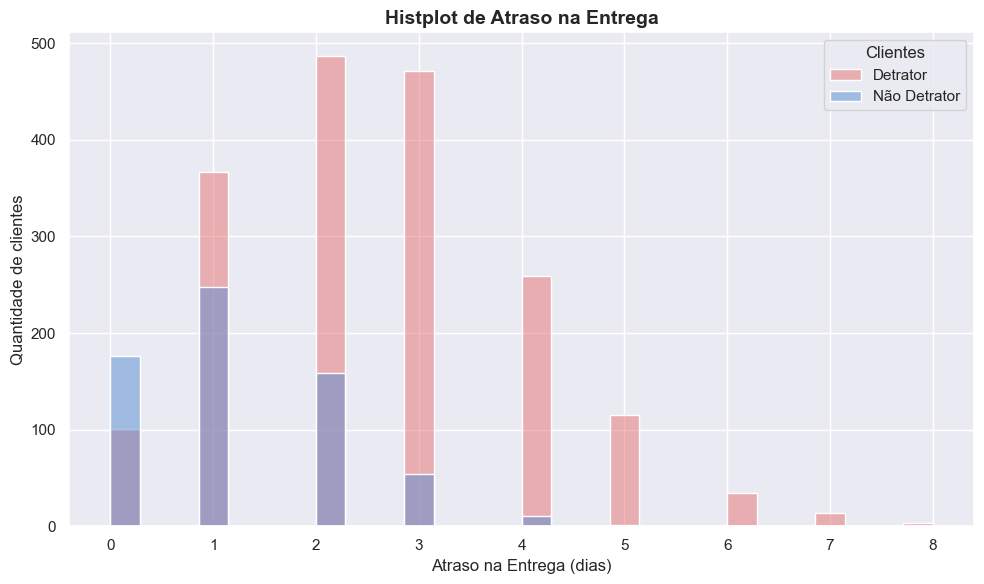

In [47]:
fig = plot_histplot(df_analise2, x_col="delivery_delay_days", hue_col="target", title="Histplot de Atraso na Entrega", xlabel="Atraso na Entrega (dias)", ylabel="Quantidade de clientes")

### 4.2.2 - Variável `customer_service_contacts`

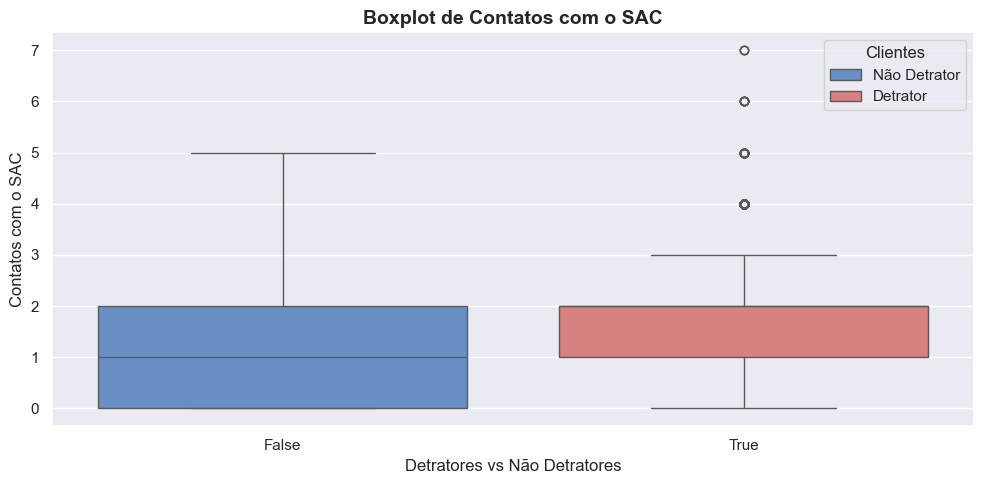

In [48]:
plot_boxplot(df_analise2, x_col="target", y_col="customer_service_contacts", hue_col="target", title="Boxplot de Contatos com o SAC", xlabel="Detratores vs Não Detratores", ylabel="Contatos com o SAC")

### 4.2.3 - Variável `complaints_count`

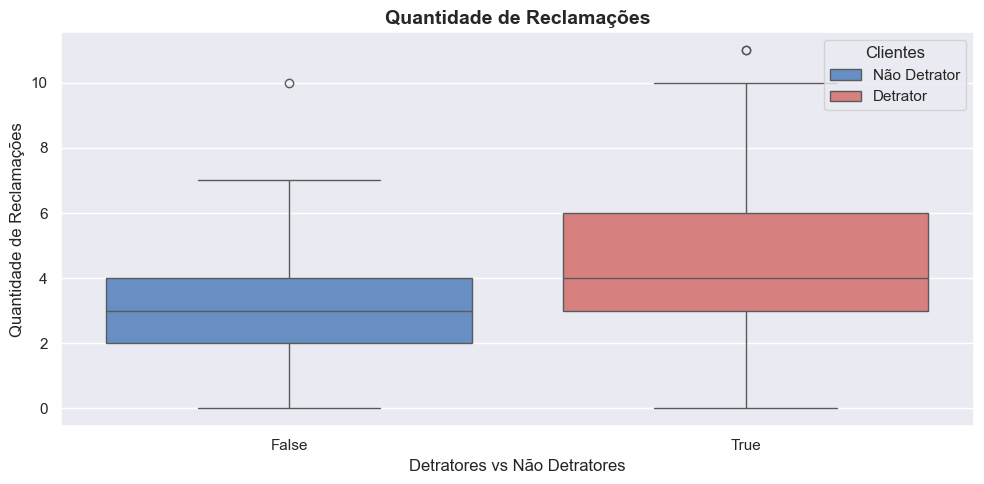

In [49]:
plot_boxplot(df_analise2, x_col="target", y_col="complaints_count", hue_col="target", title="Quantidade de Reclamações", xlabel="Detratores vs Não Detratores", ylabel="Quantidade de Reclamações")

### 4.2.4 - Variável `resolution_time_days`

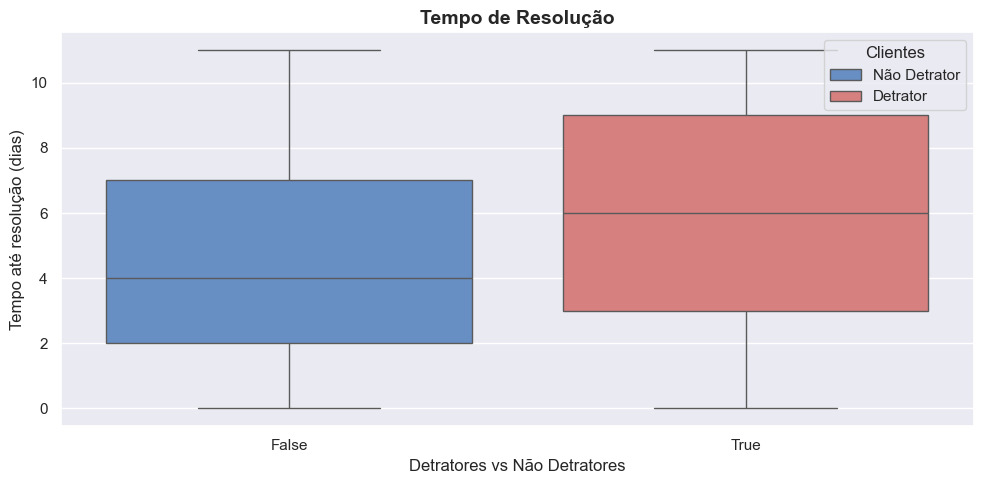

In [50]:
plot_boxplot(df_analise2, x_col="target", y_col="resolution_time_days", hue_col="target", title="Tempo de Resolução", xlabel="Detratores vs Não Detratores", ylabel="Tempo até resolução (dias)")

### 4.2.5 - Variável `csat_internal_score`

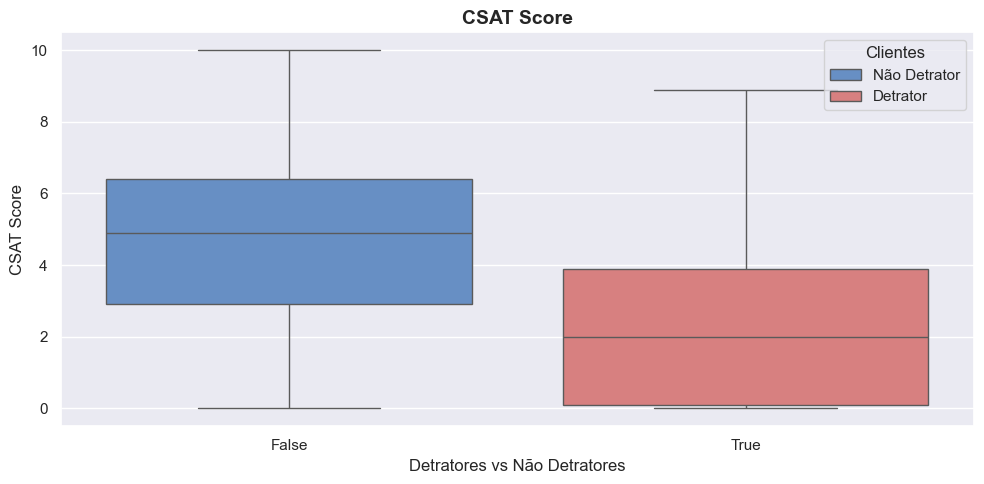

In [51]:
plot_boxplot(df_analise2, x_col="target", y_col="csat_internal_score", hue_col="target", title="CSAT Score", xlabel="Detratores vs Não Detratores", ylabel="CSAT Score")

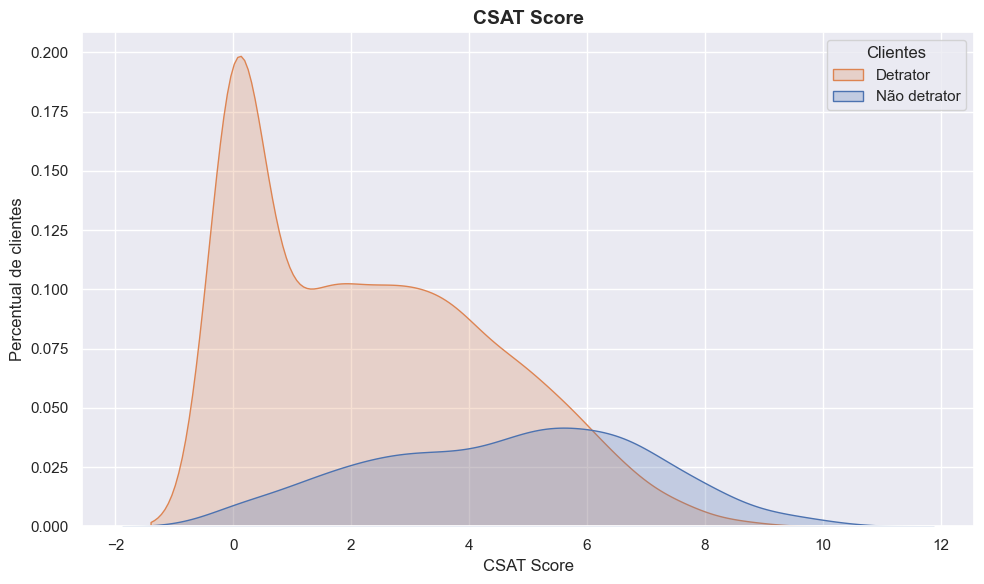

In [52]:
plot_kdeplot(df_analise2, x_col='csat_internal_score', hue_col='target', title="CSAT Score", xlabel="CSAT Score", ylabel="Percentual de clientes")

## 4.3 - Análise em relação ao NPS

Realizando a análise da relação das features de interesse e do `nps_score`

In [53]:
def plot_lineplot(df, x_col, y_col, title="", xlabel="", ylabel=""):
    plt.figure(figsize=(10, 6))
    
    ax = sns.lineplot(df, x=x_col, y=y_col, legend=True)
    
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    plt.tight_layout()
    plt.show()


### 4.3.1 - Variável `delivery_delay_days`

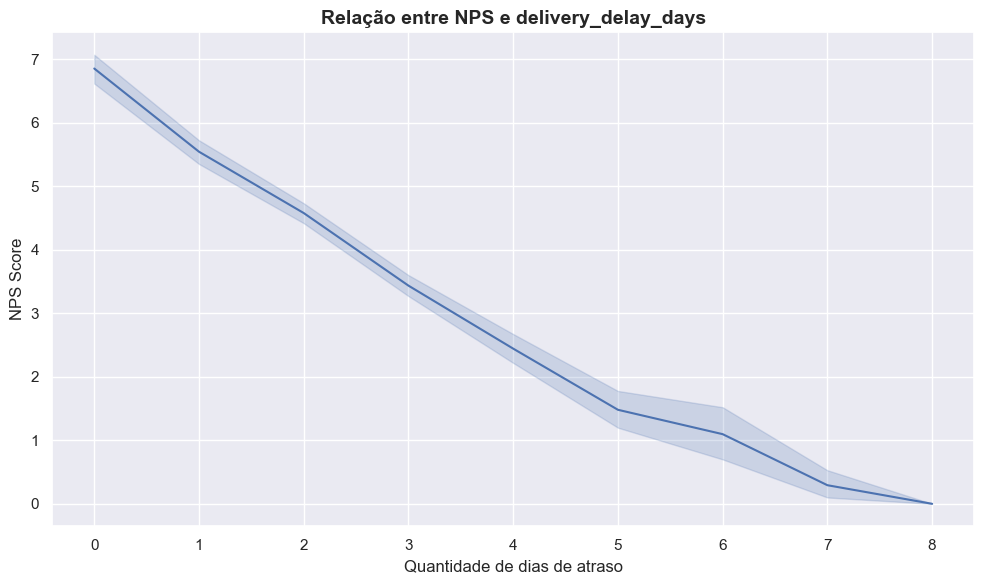

In [54]:
plot_lineplot(df_analise2, x_col='delivery_delay_days', y_col='nps_score', title="Relação entre NPS e delivery_delay_days", xlabel="Quantidade de dias de atraso", ylabel="NPS Score")

### 4.3.2 - Variável `customer_service_contacts`

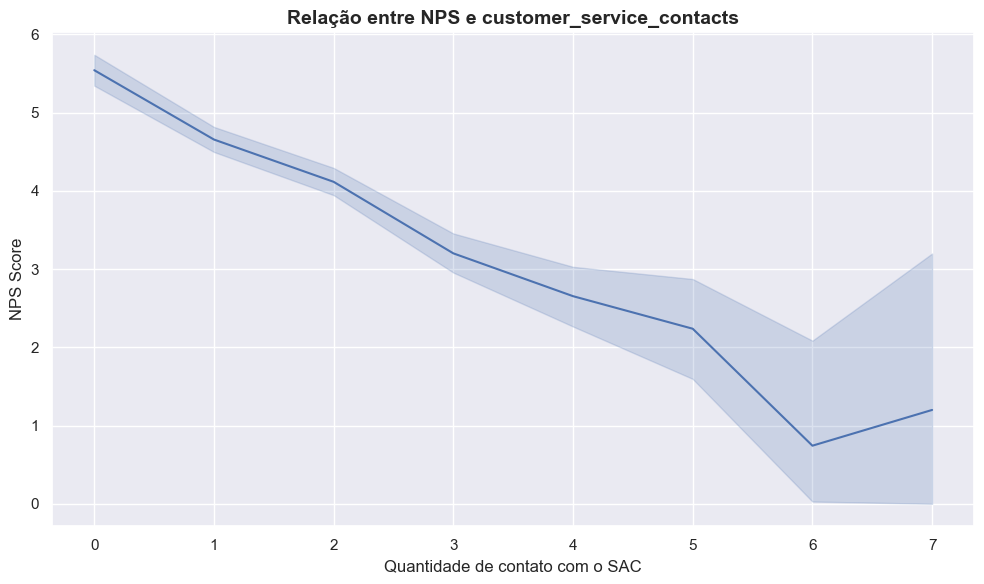

In [55]:
plot_lineplot(df_analise2, x_col='customer_service_contacts', y_col='nps_score', title="Relação entre NPS e customer_service_contacts", xlabel="Quantidade de contato com o SAC", ylabel="NPS Score")

### 4.3.3 - Variável `complaints_count`

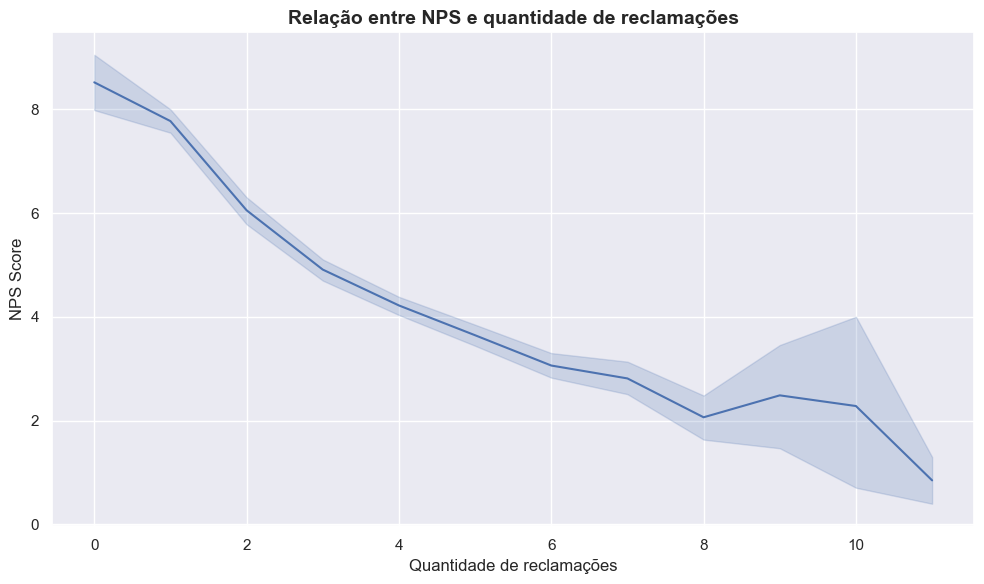

In [56]:
plot_lineplot(df_analise2, x_col='complaints_count', y_col='nps_score', title="Relação entre NPS e quantidade de reclamações", xlabel="Quantidade de reclamações", ylabel="NPS Score")

### 4.3.4 - Variável `resolution_time_days`

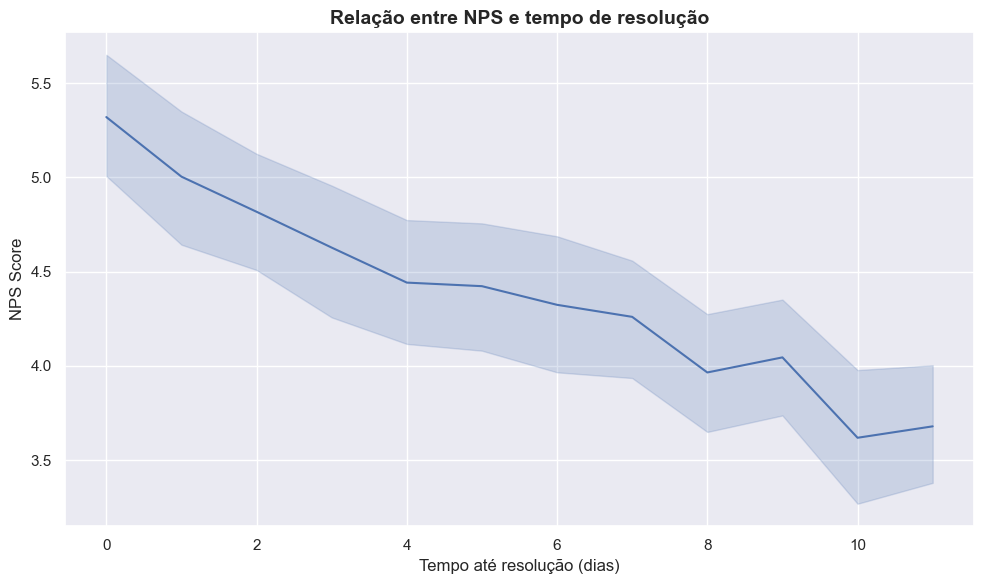

In [57]:
plot_lineplot(df_analise2, x_col='resolution_time_days', y_col='nps_score', title="Relação entre NPS e tempo de resolução", xlabel="Tempo até resolução (dias)", ylabel="NPS Score")

### 4.3.5 - Variável `csat_internal_score`

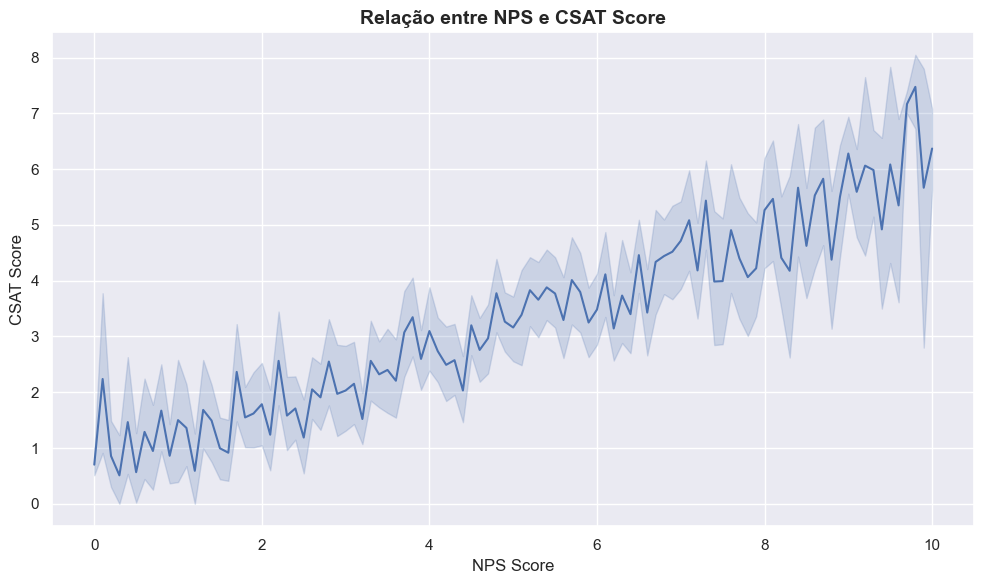

In [58]:
plot_lineplot(df_analise2, x_col='nps_score', y_col='csat_internal_score', title="Relação entre NPS e CSAT Score", xlabel="NPS Score", ylabel="CSAT Score")

# 5 - Conclusão da Análise Exploratória

Após análise das variáveis disponíveis em relação ao NPS e ao conceito de clientes Detratores, podemos concluir que as seguintes variáveis são relevantes para a definição da satisfação e lealdade do cliente:
1. complaints_count 
2. delivery_delay_days
3. customer_service_contacts
4. resolution_time_days
5. csat_internal_score
6. repeat_purchase_30d (será retirado na modelagem devido ao data_leakage)

Analisando em relação ao negócio, a principal raíz das dores dos clientes são os atrasos na entrega.

Imagina-se que o fluxo dos problemas seja:

Atraso na entrega -> Reclamação/Concato com SAC -> Tempo de resolução do problema

Logo, a forma otimizada que a empresa possui de abordar o problema do NPS é **melhorar a atraso na entrega**. <br>
Uma vez que o tempo de entrega não possui grande correlação com o NPS, uma das formas de melhorar o NPS seria **estimar o tempo de entrega de forma conservadora**.